In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv('placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [25]:
df.shape

(100, 4)

# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model
     

In [26]:
# 0. Preprocess + EDA + Feature Selection
df = df.iloc[:,1:] # All rows all column expect 1st
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


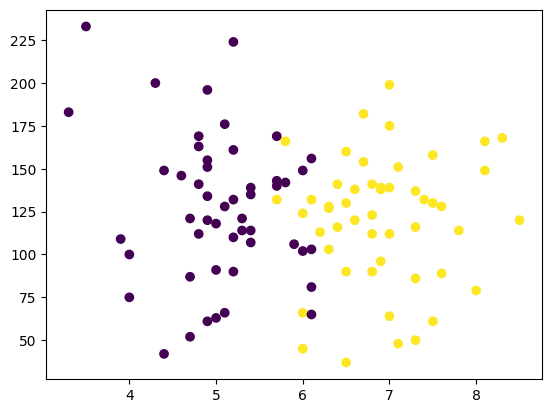

In [27]:
# EDA :
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [28]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [29]:
y.shape

(100,)

In [30]:
# Train Test Split:
from sklearn.model_selection import train_test_split

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1) 

In [32]:
X_train

,cgpa,iq
41,5.4,114.0
21,7.1,151.0
1,5.9,106.0
45,6.0,66.0
9,5.1,66.0
...,...,...
13,6.4,116.0
27,6.0,124.0
65,8.1,166.0
34,4.8,163.0


In [33]:
y_train

41    0
21    1
1     0
45    1
9     0
     ..
13    1
27    1
65    1
34    0
67    0
Name: placement, Length: 90, dtype: int64

In [34]:
X_test

,cgpa,iq
0,6.8,123.0
18,4.0,100.0
48,6.6,138.0
62,6.0,102.0
79,6.5,90.0
55,7.8,114.0
14,6.1,103.0
64,7.0,64.0
75,4.8,169.0
92,5.2,110.0


In [35]:
# Scale the values:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [36]:
X_train = scaler.fit_transform(X_train)
X_train

array([[-0.50776675, -0.26887225],
       [ 0.97766944,  0.64010702],
       [-0.07087375, -0.46540831],
       [ 0.01650485, -1.4480886 ],
       [-0.76990255, -1.4480886 ],
       [-2.34271734,  1.42625126],
       [ 0.45339784,  0.12419987],
       [ 1.15242664, -0.95674845],
       [-0.94465975, -1.57092364],
       [ 1.41456244, -0.88304743],
       [ 0.10388345, -1.47265561],
       [ 0.62815504,  1.40168425],
       [-1.11941695, -0.93218145],
       [-0.15825235,  0.41900396],
       [-0.59514535, -0.0969032 ],
       [ 0.62815504,  0.71380805],
       [-0.94465975,  1.74562235],
       [ 0.54077644, -0.1214702 ],
       [-0.68252395,  0.17333389],
       [ 0.27864065, -0.53910933],
       [ 0.89029084,  1.81932338],
       [-0.85728115, -0.83391342],
       [ 1.15242664, -0.21973823],
       [ 0.80291224, -0.71107838],
       [-0.94465975,  0.2224679 ],
       [ 1.23980524,  0.17333389],
       [ 1.85145544,  0.59097301],
       [ 0.10388345,  0.76294206],
       [-0.50776675,

In [37]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [38]:
# Model Training:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
y_pred = lr.predict(X_test)
y_test

/home/zaid/.venvs/kaggle-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0     1
18    0
48    1
62    0
79    1
55    1
14    0
64    1
75    0
92    0
Name: placement, dtype: int64

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6

In [41]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

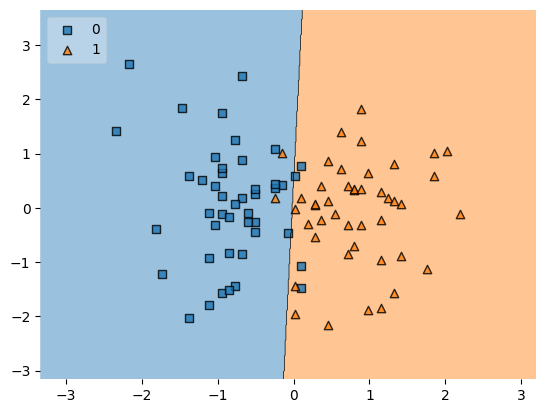

In [ ]:
plot_decision_regions(X_train,y_train.values, clf=lr, legend = 2)
# Convert only y_train in vecters bcz X_train is already 
# converted when we applied standard scaler. 

In [43]:
import pickle

In [44]:
pickle.dump(lr,open('model.pkl','wb'))
# given the the name model.pkl to the folder of lr model in write binary mode.